In [1]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPModel, CLIPProcessor

ML_DIR = Path.cwd().parent
CACHE = ML_DIR / "data" / "cached"
IMG_DIR = ML_DIR / "data" / "raw" / "fashion-dataset" / "images"

img_emb = np.load(CACHE / "clip_image_embeddings.npy")
img_ids = np.load(CACHE / "clip_image_ids.npy")
txt_emb = np.load(CACHE / "clip_text_embeddings.npy")
txt_ids = np.load(CACHE / "clip_text_ids.npy")
meta = pd.read_csv(CACHE / "metadata_clean.csv")
captions = pd.read_csv(CACHE / "captions.csv")

# both arrays should be ordered the same way, but verify
assert np.array_equal(img_ids, txt_ids), "id order mismatch between image and text embeddings!"
print("image and text embeddings aligned. all good.")

id_to_idx = {int(i): k for k, i in enumerate(img_ids)}

print("image emb:", img_emb.shape)
print("text emb:", txt_emb.shape)
print("metadata:", meta.shape)

image and text embeddings aligned. all good.
image emb: (44419, 512)
text emb: (44419, 512)
metadata: (44419, 11)


In [2]:
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(DEVICE)
model.eval()
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

@torch.no_grad()
def encode_text(query):
    inputs = processor(text=[query], return_tensors="pt", padding=True, truncation=True, max_length=77)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    out = model.text_model(**inputs)
    feat = model.text_projection(out.pooler_output)
    feat = feat / feat.norm(dim=-1, keepdim=True)
    return feat.cpu().numpy()[0]

print("text encoder ready")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

text encoder ready


In [3]:
def text_search(query, top_k=8):
    q_vec = encode_text(query)
    sims = img_emb @ q_vec
    top_idx = np.argpartition(-sims, top_k)[:top_k]
    top_idx = top_idx[np.argsort(-sims[top_idx])]
    return [(int(img_ids[i]), float(sims[i])) for i in top_idx]


def show_text_results(query, top_k=8):
    results = text_search(query, top_k=top_k)
    fig, axes = plt.subplots(1, top_k, figsize=(2 * top_k, 3))
    for ax, (rid, sim) in zip(axes, results):
        r_meta = meta[meta['id'] == rid].iloc[0]
        img = Image.open(IMG_DIR / f"{rid}.jpg")
        ax.imshow(img)
        ax.set_title(f"sim={sim:.3f}\n{r_meta['articleType']}\n{r_meta['baseColour']}", fontsize=7)
        ax.axis('off')
    fig.suptitle(f'"{query}"', fontsize=12)
    plt.tight_layout()
    plt.show()

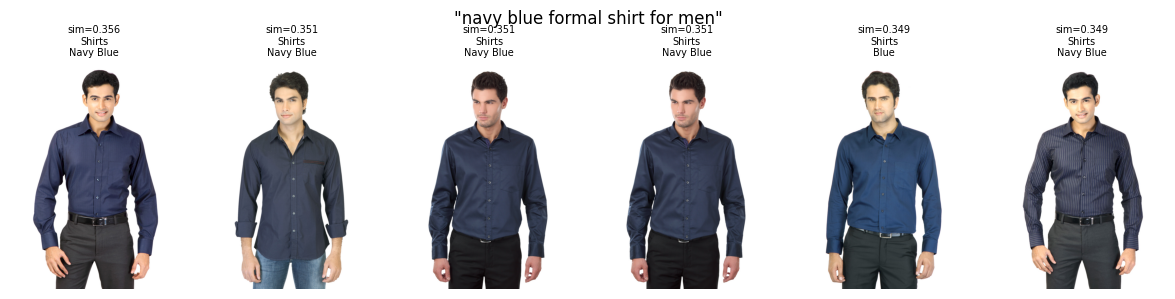

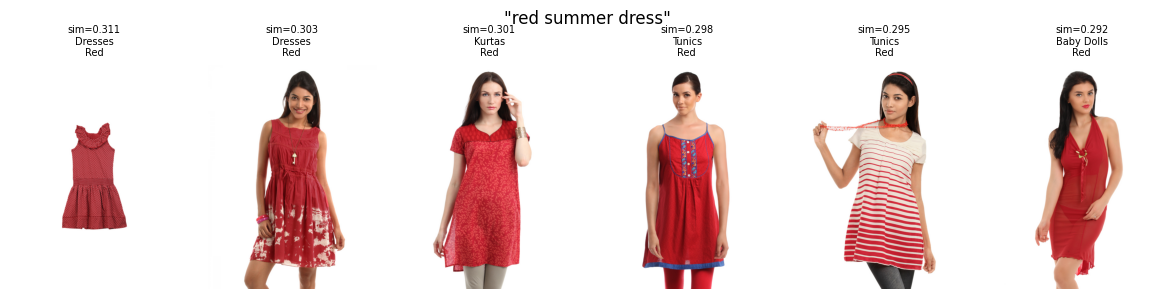

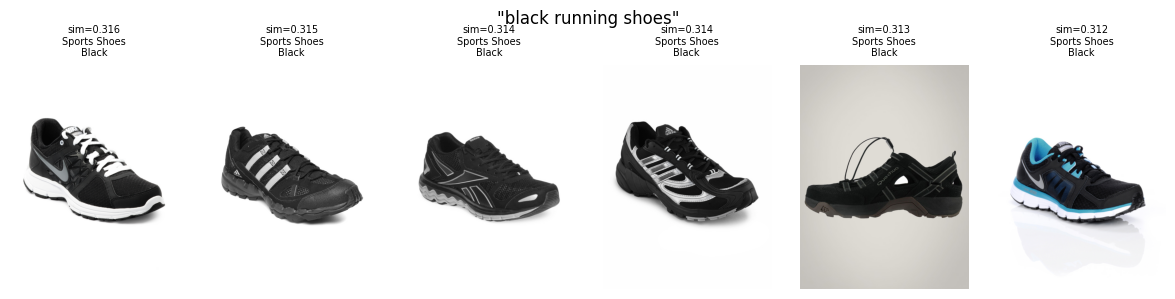

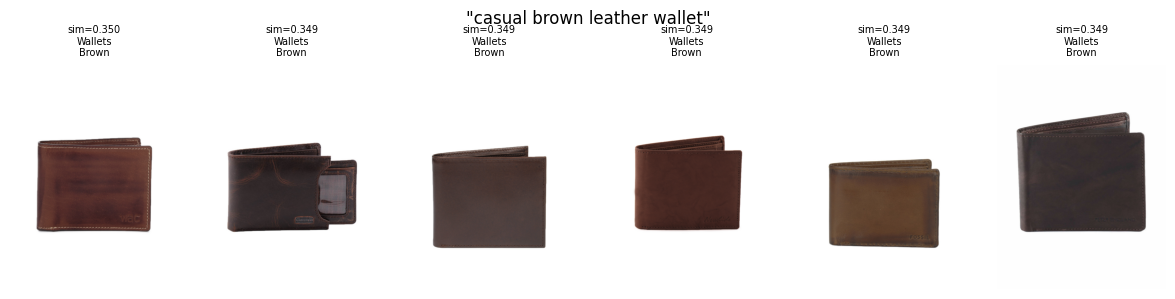

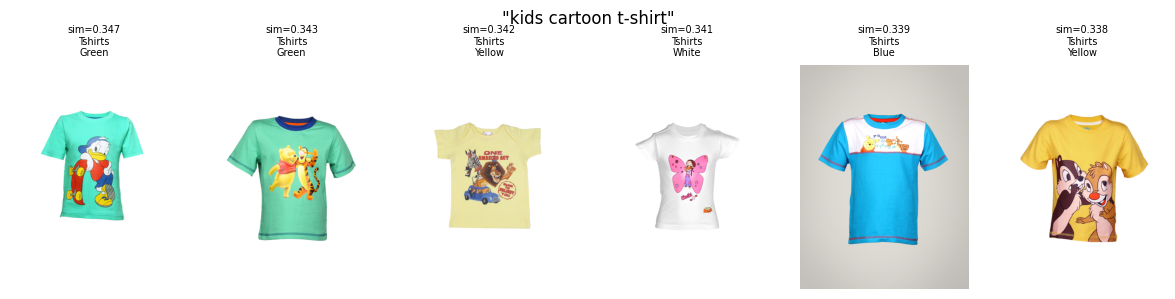

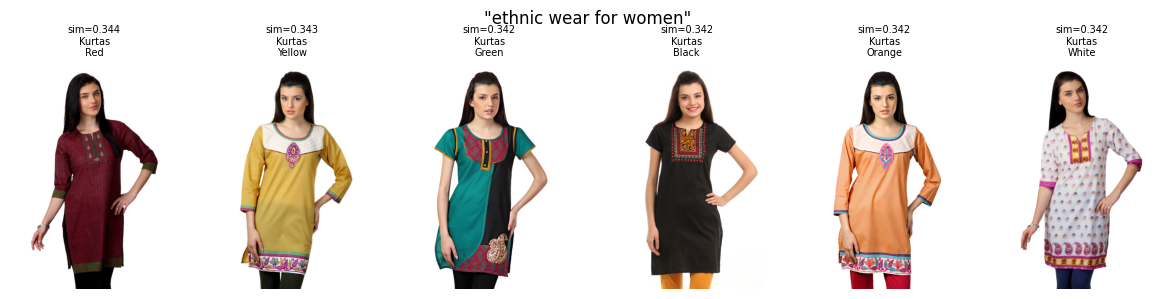

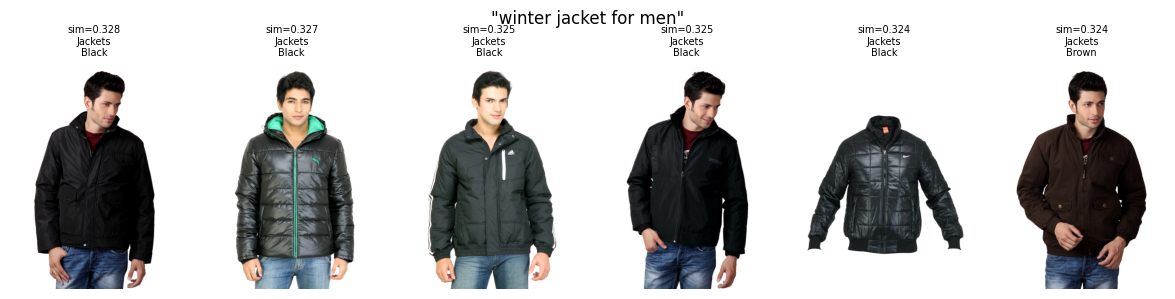

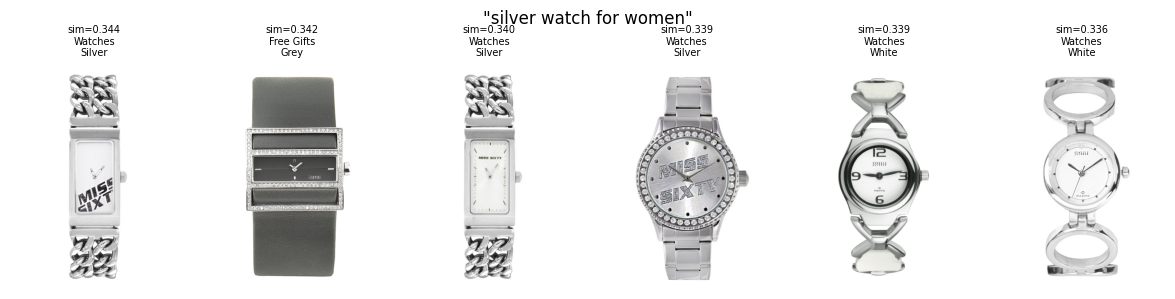

In [4]:
test_queries = [
    "navy blue formal shirt for men",
    "red summer dress",
    "black running shoes",
    "casual brown leather wallet",
    "kids cartoon t-shirt",
    "ethnic wear for women",
    "winter jacket for men",
    "silver watch for women",
]

for q in test_queries:
    show_text_results(q, top_k=6)

In [5]:
def caption_recall(num_queries=2000, ks=(1, 5, 10, 20), seed=42):
    """sample products. use each product's caption as query.
    measure how often the source product appears in top-k retrieved images."""
    np.random.seed(seed)
    sample_idx = np.random.choice(len(img_ids), num_queries, replace=False)
    hits = {k: 0 for k in ks}

    for i in sample_idx:
        # the caption embedding for this product is already in txt_emb at the same index
        q_vec = txt_emb[i]
        sims = img_emb @ q_vec
        # rank of the true product
        true_sim = sims[i]
        rank = (sims > true_sim).sum() + 1  # how many items have strictly higher sim than truth
        for k in ks:
            if rank <= k:
                hits[k] += 1

    for k in ks:
        print(f"recall@{k}: {hits[k] / num_queries:.4f}")
    return {k: hits[k] / num_queries for k in ks}


print("baseline text-to-image retrieval (caption as query):")
baseline_recall = caption_recall(num_queries=2000)

baseline text-to-image retrieval (caption as query):
recall@1: 0.0430
recall@5: 0.1205
recall@10: 0.1860
recall@20: 0.2575


In [6]:
def attribute_match_eval(query, expected_article=None, expected_color=None, top_k=10):
    results = text_search(query, top_k=top_k)
    rids = [r[0] for r in results]
    rmeta = meta[meta['id'].isin(rids)]
    out = {}
    if expected_article:
        out['article_match'] = (rmeta['articleType'].str.lower().str.contains(expected_article.lower())).mean()
    if expected_color:
        out['color_match'] = (rmeta['baseColour'].str.lower() == expected_color.lower()).mean()
    return out


eval_queries = [
    ("navy blue formal shirt for men", "shirt", "Navy Blue"),
    ("red dress for women",            "dress", "Red"),
    ("black running shoes",            "shoe",  "Black"),
    ("brown leather wallet",           "wallet","Brown"),
    ("silver watch for women",         "watch", "Silver"),
    ("white casual sneakers",          "casual shoe", "White"),
]

print(f"\n{'query':<40} {'article@10':>12} {'color@10':>12}")
print("-" * 64)
for q, art, col in eval_queries:
    r = attribute_match_eval(q, art, col, top_k=10)
    print(f"{q:<40} {r.get('article_match', 0):>12.3f} {r.get('color_match', 0):>12.3f}")


query                                      article@10     color@10
----------------------------------------------------------------
navy blue formal shirt for men                  1.000        0.600
red dress for women                             0.100        1.000
black running shoes                             1.000        1.000
brown leather wallet                            1.000        0.900
silver watch for women                          0.900        0.300
white casual sneakers                           0.700        0.900
